## **#Q3 Task1 : Date Feature Engineering**

In [1]:
import pandas as pd

df = pd.read_csv('../data/q3_retail_promotions.csv')

# Convert to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# Month end feature
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

# Display sample
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


Date-based features such as year, month, and day of week are extracted to capture seasonal and weekly patterns in sales.
The is_month_end feature is created to capture potential spikes in sales toward the end of the month, which may be influenced by salary cycles or promotional strategies.

## **#Q3 Task2 : Temporal Train-Test Split**

In [2]:
# Sort data by date
df = df.sort_values(by='transaction_date')

# Split index
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

A random train-test split is inappropriate for time-ordered data because it can lead to data leakage, where future information is used to predict past outcomes.
By using a temporal split, the model is trained only on past data and evaluated on future data, which better reflects real-world forecasting scenarios.

## **#Q3 Task3 : Preprocessing Pipeline**

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Target
y_train = train_df['items_sold']
y_test = test_df['items_sold']

# Drop target + date
X_train = train_df.drop(['items_sold', 'transaction_date'], axis=1)
X_test = test_df.drop(['items_sold', 'transaction_date'], axis=1)

# Categorical & Numerical columns
categorical_cols = ['promotion_type', 'location_type', 'store_size']
numerical_cols = [col for col in X_train.columns if col not in categorical_cols]

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ]
)

## **#Q3 Task4 : Model Training and Evaluation**

In [4]:
# Linear Regression Pipeline

from sklearn.linear_model import LinearRegression

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)

In [5]:
# Random Forest Pipeline

from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

In [6]:
# Evaluation metrics

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    
    print(f"\n{name}")
    print("RMSE:", rmse)
    print("MAE:", mae)

evaluate("Linear Regression", y_test, y_pred_lr)
evaluate("Random Forest", y_test, y_pred_rf)


Linear Regression
RMSE: 27.12145116489062
MAE: 21.052926674588395

Random Forest
RMSE: 31.660007317329118
MAE: 24.87391666666667


The performance of the two models was evaluated using RMSE and MAE on the test set.

Linear Regression achieved a lower RMSE (~27.12) and MAE (~21.05) compared to Random Forest, which had RMSE (~31.66) and MAE (~24.87).

This indicates that Linear Regression performs better for this dataset. One possible reason is that the relationship between features and items sold is relatively linear, allowing the simpler model to generalize more effectively.

In contrast, the Random Forest model may be overfitting to noise in the training data, leading to slightly worse performance on the test set.

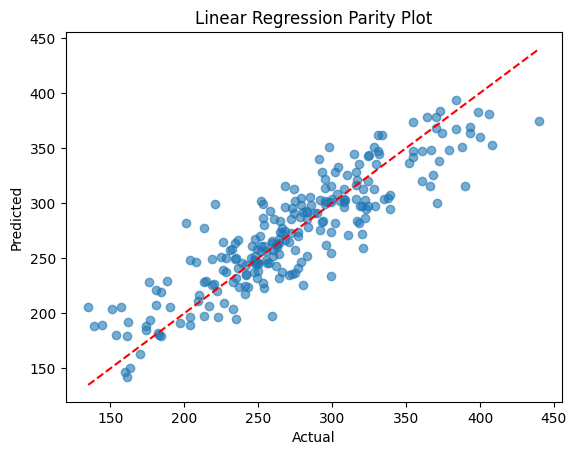

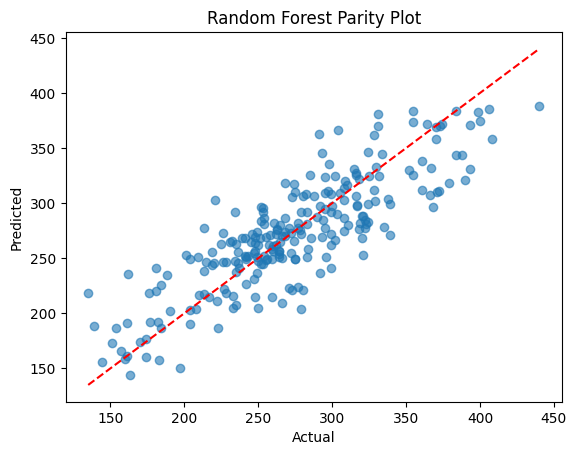

In [7]:
# Parity plots

import matplotlib.pyplot as plt

def parity_plot(y_true, y_pred, title):
    plt.scatter(y_true, y_pred, alpha=0.6)
    plt.plot([y_true.min(), y_true.max()],
             [y_true.min(), y_true.max()],
             'r--')
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.show()

parity_plot(y_test, y_pred_lr, "Linear Regression Parity Plot")
parity_plot(y_test, y_pred_rf, "Random Forest Parity Plot")

The parity plots compare predicted values with actual values for both models.

For Linear Regression, the points are closely aligned along the diagonal reference line, indicating good predictive accuracy and consistency.

In comparison, the Random Forest model shows greater dispersion around the diagonal, suggesting less accurate predictions and higher error variance.

Overall, the Linear Regression model demonstrates better alignment with actual values and more stable predictions.

In [8]:
# Get feature names after encoding

ohe = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat']
encoded_cols = ohe.get_feature_names_out(categorical_cols)

all_features = list(encoded_cols) + numerical_cols

# Importances
importances = rf_pipeline.named_steps['model'].feature_importances_

feat_importance_df = pd.DataFrame({
    'feature': all_features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feat_importance_df.head(5)

,feature,importance
7,store_size_small,0.183954
10,is_festival,0.174477
5,location_type_urban,0.140498
14,day_of_week,0.090612
9,is_weekend,0.063547


The Random Forest model identifies the following features as the most important predictors of sales:

store_size_small
is_festival
location_type_urban
day_of_week
is_weekend

These results suggest that store characteristics and temporal factors play a significant role in influencing sales.

In particular, smaller store sizes and festival periods have a strong impact on items sold, while location type and weekly patterns also contribute meaningfully to sales variation.